# Importación de librerías y descarga de imagen de prueba

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
# Importar ipywidgets para el Bonus interactivo en Colab
from ipywidgets import interact, FloatSlider, IntSlider

# Descargar una imagen de prueba (Lenna) desde el repositorio oficial de OpenCV
url = 'https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg'
urllib.request.urlretrieve(url, 'imagen_prueba.png')

# Función auxiliar para mostrar imágenes en Colab con Matplotlib
def mostrar_imagen(img, titulo="Imagen", cmap=None):
    plt.figure(figsize=(6, 6))
    if cmap:
        plt.imshow(img, cmap=cmap)
    else:
        # OpenCV lee en BGR, Matplotlib muestra en RGB
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img_rgb)
    plt.title(titulo)
    plt.axis('off')
    plt.show()Ss

# Cargar imagen y separar canales (RGB y HSV)

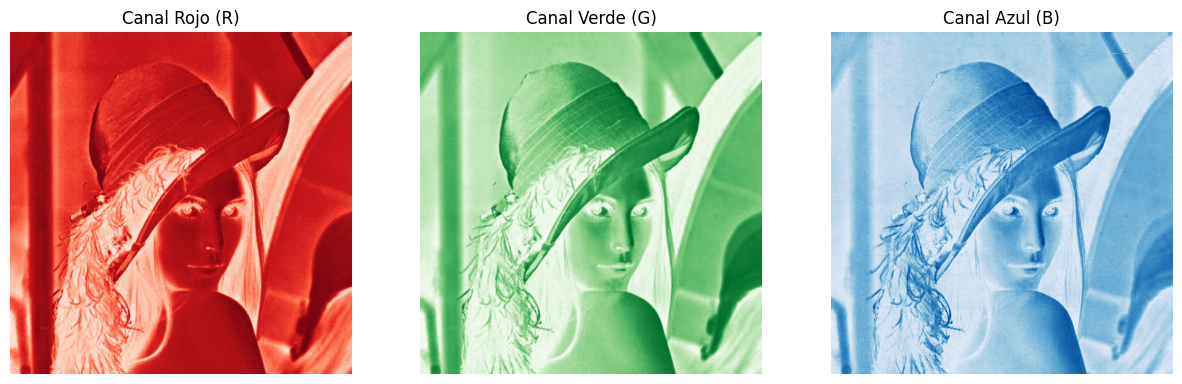

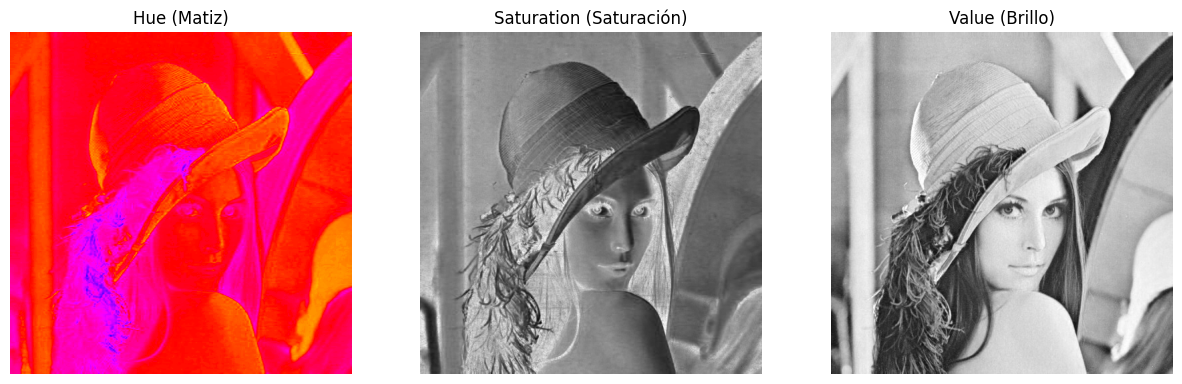

In [ ]:
# Cargar la imagen
img_bgr = cv2.imread('imagen_prueba.png')

# 1. Canales RGB
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
R, G, B = cv2.split(img_rgb)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(R, cmap='Reds')
axs[0].set_title('Canal Rojo (R)')
axs[0].axis('off')

axs[1].imshow(G, cmap='Greens')
axs[1].set_title('Canal Verde (G)')
axs[1].axis('off')

axs[2].imshow(B, cmap='Blues')
axs[2].set_title('Canal Azul (B)')
axs[2].axis('off')
plt.show()

# 2. Canales HSV
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
H, S, V = cv2.split(img_hsv)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(H, cmap='hsv')
axs[0].set_title('Hue (Matiz)')
axs[0].axis('off')

axs[1].imshow(S, cmap='gray')
axs[1].set_title('Saturation (Saturación)')
axs[1].axis('off')

axs[2].imshow(V, cmap='gray')
axs[2].set_title('Value (Brillo)')
axs[2].axis('off')
plt.show()

# Slicing de matrices (Modificación de regiones)

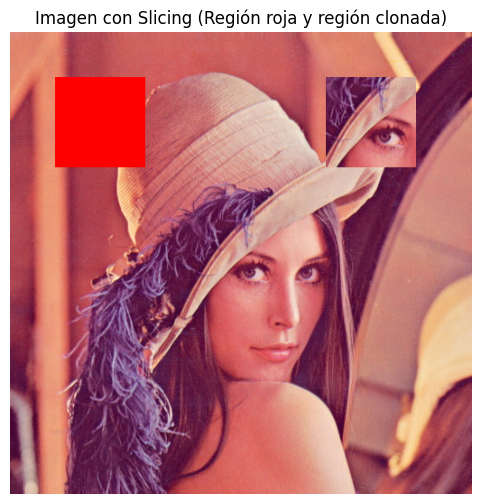

In [ ]:
# Crear una copia para no alterar la original
img_modificada = img_bgr.copy()

# 1. Cambiar el color de un área rectangular (e.g., un cuadro rojo en la esquina superior izquierda)
# Formato de matriz: img[y_inicio:y_fin, x_inicio:x_fin]
# Asignamos color BGR: Azul=0, Verde=0, Rojo=255
img_modificada[50:150, 50:150] = [0, 0, 255]

# 2. Sustituir una región por otra parte de la imagen
# Vamos a copiar un parche del centro y pegarlo en la esquina superior derecha
parche = img_bgr[200:300, 200:300]
img_modificada[50:150, 350:450] = parche

mostrar_imagen(img_modificada, "Imagen con Slicing (Región roja y región clonada)")

# Histograma de intensidades

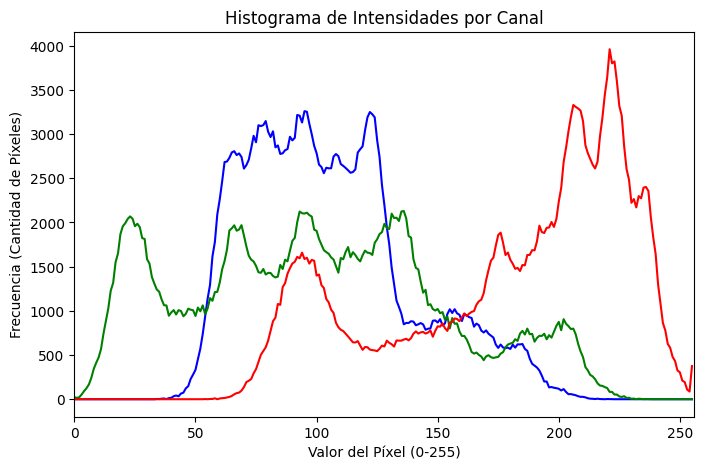

In [ ]:
colores = ('b', 'g', 'r')
plt.figure(figsize=(8, 5))
plt.title('Histograma de Intensidades por Canal')
plt.xlabel('Valor del Píxel (0-255)')
plt.ylabel('Frecuencia (Cantidad de Píxeles)')

# Calcular y graficar con cv2.calcHist para cada canal
for i, col in enumerate(colores):
    # cv2.calcHist(images, channels, mask, histSize, ranges)
    hist = cv2.calcHist([img_bgr], [i], None, [256], [0, 256])
    plt.plot(hist, color=col)
    plt.xlim([0, 256])

plt.show()

# Ajustes de Brillo y Contraste

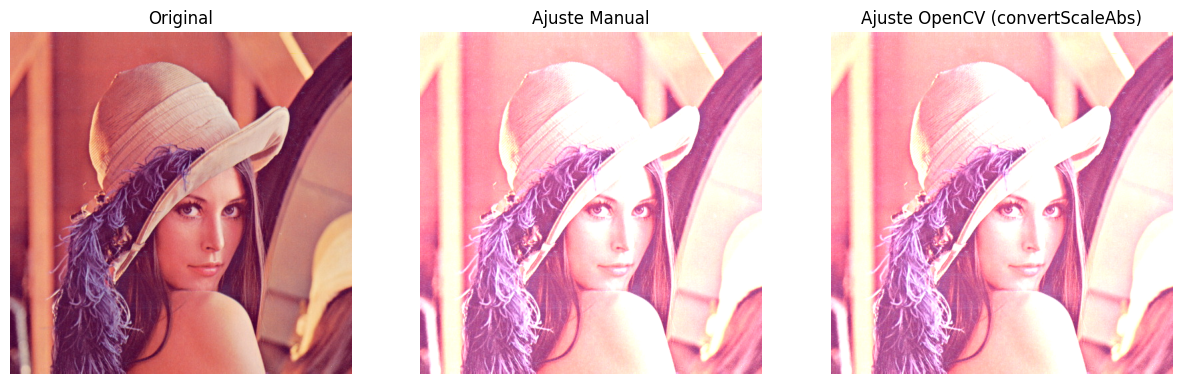

In [ ]:
alpha = 1.5 # Contraste (> 1 incrementa, < 1 disminuye)
beta = 50   # Brillo (Valores positivos iluminan, negativos oscurecen)

# 1. Forma Manual (Ecuación)
# Multiplicamos por alpha, sumamos beta, y limitamos los valores entre 0 y 255 con np.clip
img_manual = np.clip(alpha * img_bgr + beta, 0, 255).astype(np.uint8)

# 2. Con funciones de OpenCV
img_opencv = cv2.convertScaleAbs(img_bgr, alpha=alpha, beta=beta)

# Mostrar resultados
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
axs[0].set_title('Original')
axs[0].axis('off')

axs[1].imshow(cv2.cvtColor(img_manual, cv2.COLOR_BGR2RGB))
axs[1].set_title('Ajuste Manual')
axs[1].axis('off')

axs[2].imshow(cv2.cvtColor(img_opencv, cv2.COLOR_BGR2RGB))
axs[2].set_title('Ajuste OpenCV (convertScaleAbs)')
axs[2].axis('off')

plt.show()

# BONUS - Sliders interactivos en Colab

In [ ]:
# Función para interactuar
def ajustar_imagen(alpha=1.0, beta=0):
    img_ajustada = cv2.convertScaleAbs(img_bgr, alpha=alpha, beta=beta)

    # Mostrar la imagen
    plt.figure(figsize=(7, 7))
    plt.imshow(cv2.cvtColor(img_ajustada, cv2.COLOR_BGR2RGB))
    plt.title(f'Contraste (Alpha): {alpha} | Brillo (Beta): {beta}')
    plt.axis('off')
    plt.show()

# Crear los sliders
interact(ajustar_imagen,
         alpha=FloatSlider(min=0.1, max=3.0, step=0.1, value=1.0, description='Contraste (α):'),
         beta=IntSlider(min=-100, max=100, step=1, value=0, description='Brillo (β):'));

interactive(children=(FloatSlider(value=1.0, description='Contraste (α):', max=3.0, min=0.1), IntSlider(value=…